# A quickstart guide

**Load, visualize, enrich, summarize, split, and segment a GPS track with Tracklib**

This quickstart introduces the core features of Tracklib through a simple GPS trajectory representing a running training session on an athletics track.

You will learn how to load GPS data, visualize the trajectory, compute derived features such as speed and curvilinear abscissa, and use these features to explore the track. Finally, you will see how to segment the trajectory automatically based on detected changes in speed.

## Importing Tracklib


In [1]:
import matplotlib.pyplot as plt

import os
import sys

# Import the Tracklib library
import tracklib as tkl

Code running in a no shapely environment


## Reading GPS Data, Transforming Coordinates, and Printing a Summary

In [2]:
# ---------------------------------------------------
# Loading the GPS Data
# ---------------------------------------------------
tkl.ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")
tracks = tkl.TrackReader.readFromFile('../../../data/gpx/activity_5807084803.gpx', tkl.TrackFormat({'ext': 'GPX'}))
trace = tracks.getTrack(0)

# Transformation GEO coordinates to ENU
trace.toENUCoords()

# Summary
trace.summary()

-------------------------------------
GPS track #0 of user 0:
-------------------------------------
  Nb of pt(s):   190
  Ref sys id   : ENU
  Starting at  : 11/11/2020 15:39:54
  Ending at    : 11/11/2020 15:52:00
  Duration     : 726.000 s
  Length       : 2412.144 m
-------------------------------------



## Visualizing the GPS Track

The track can be displayed in different coordinate systems:

- **Figure 1:** Cartesian coordinate system.
- **Figure 2:** Circular coordinate system.

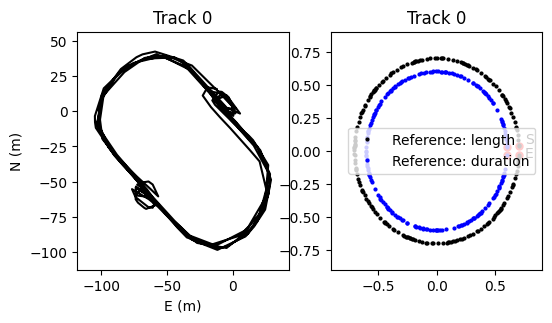

In [3]:
plt.figure(figsize=(6, 2))
plt.subplots_adjust(top=1.3, wspace=0.2, hspace=0.2)

# GPS track in a cartesian coordinate system
ax1 = plt.subplot2grid((1, 2), (0, 0))
trace.plot(type='LINE', append=ax1)

#
ax2 = plt.subplot2grid((1, 2), (0, 1))
trace.plot(type='CIRCULAR', append=ax2)

plt.show()

## Computing Local Speed

The *estimate_speed()* method computes the local speed at each observation along the track and stores the result in an analytical feature named *speed*.

For the first and last observations, the speed is copied from the first and last valid estimates, respectively. For all intermediate observations, the local speed is computed using the previous and the next observations:

$$
\mathrm{speed}(i)=
\frac{d(\mathrm{point}_{i-1},\mathrm{point}_{i+1})}
{t_{i+1}-t_{i-1}}
$$

where:

- $d(\cdot,\cdot)$ is the distance between two observations.
- $t_i$ is the timestamp of observation $i$.

This centered estimate provides a smoother approximation of the instantaneous speed than a simple forward or backward difference.

In [4]:
# Compute local speed
trace.estimate_speed()
print ('')

# Get all speed values
SPEEDS = trace.getAnalyticalFeature('speed')

# Display the top ten speeds
print (SPEEDS[0:10])


[4.55221497831179, 6.255327113366183, 5.896832339965242, 4.978192041525976, 5.334848802884135, 5.503904742096748, 4.541114070830664, 4.5655781449843715, 4.272215133699211, 4.3784508497879155]


## Visualizing Speed

The following visualizations provide different views of the estimated speed along the track:

- **Figure 1:** Box plot of the speed values.
- **Figure 2:** GPS track colored by speed.
- **Figure 3:** Speed profile along the curvilinear abscissa.

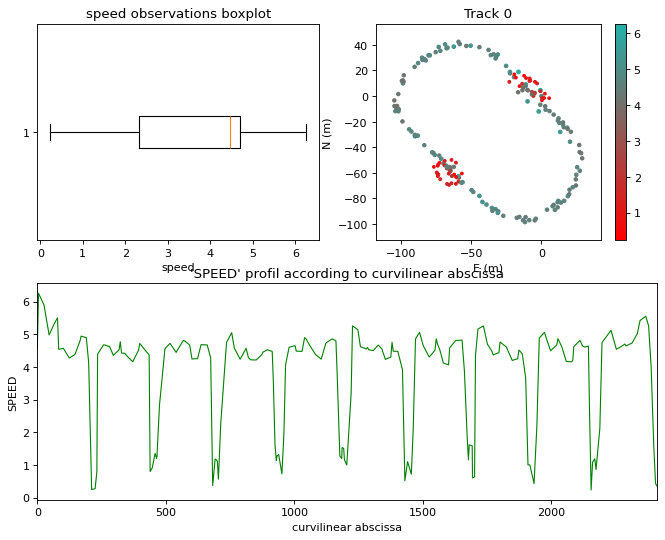

In [5]:
plt.figure(figsize=(10, 5), dpi=80)
plt.subplots_adjust(top=1.3, wspace=0.2, hspace=0.2)

# 
ax1 = plt.subplot2grid((2, 2), (0, 0))
trace.plotAnalyticalFeature('speed', 'BOXPLOT', append=ax1) 

# Display the GPS data, color depends on speed
ax2 = plt.subplot2grid((2, 2), (0, 1))
trace.plot(type='POINT', af_name='speed', append=ax2)

# Display the speed profil along the curvilinear abscissa
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
trace.plotProfil('SPATIAL_SPEED_PROFIL', append=ax3)

## Summarizing Analytical Features

Tracklib can aggregate analytical features (quantitative measures) into a regular grid. For each grid cell, statistics such as the average speed, the dominant direction, or the minimum acceleration can be computed.

In this example, the track is summarized on a grid with **3 × 3 meter** cells.

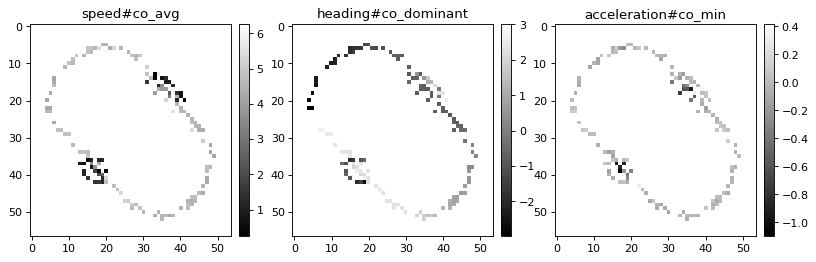

In [6]:
collection = tkl.TrackCollection([trace])

trace.addAnalyticalFeature(tkl.acceleration)
trace.addAnalyticalFeature(tkl.heading)

af_algos = [tkl.speed, tkl.heading, tkl.acceleration]
cell_operators = [tkl.co_avg, tkl.co_dominant, tkl.co_min]
marge = 0.1
res = (3,3)
raster = tkl.summarize(collection, af_algos, cell_operators, res, marge)

plt.figure(figsize=(12, 10), dpi=80)
plt.subplots_adjust(top=1.3, wspace=0.2, hspace=0.2)

ax1 = plt.subplot2grid((1, 3), (0, 0))
map1 = raster.getAFMap('speed#co_avg')
map1.plotAsImage(append=ax1)

ax2 = plt.subplot2grid((1, 3), (0, 1))
map2 = raster.getAFMap('heading#co_dominant')
map2.plotAsImage(append=ax2)

ax3 = plt.subplot2grid((1, 3), (0, 2))
map3 = raster.getAFMap('acceleration#co_min')
map3.plotAsImage(append=ax3)

## Computing Speed Changes

The speed change is computed as the absolute difference between the speeds at two consecutive observations.

1. Compute the speed difference:

   $$
   dv_i = v_i - v_{i-1}
   $$

   This is done using the **Differentiator** operator.

2. Compute the absolute speed difference:

   $$
   absdv_i = |dv_i|
   $$

   Then apply the **Rectifier** operator to obtain the absolute value of the speed difference.


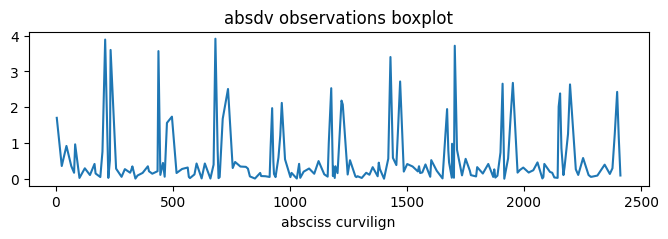

In [7]:
trace.operate(tkl.Operator.DIFFERENTIATOR, "speed", "dv")
trace.operate(tkl.Operator.RECTIFIER, "dv", "absdv")

# Speed change according to the curvilinear abscissa
trace.plotAnalyticalFeature("absdv", "PLOT")

## Segmenting the Track

Once the speed change feature has been computed, the track can be split into a collection of subtracks. In this example, the track is split whenever the absolute speed change exceeds **1.5 m/s**. Segments containing fewer than **50 observations** are discarded.

The resulting segments are then interpolated using spline interpolation. Finally, several speed-related indicators are computed for each segment.

Rep 1 :  vmoy =  17.22 km/h   vmax =  22.81  km/h   vc =  16.67 km/h
Rep 2 :  vmoy =  16.39 km/h   vmax =  17.7  km/h   vc =  16.18 km/h
Rep 3 :  vmoy =  16.72 km/h   vmax =  17.94  km/h   vc =  16.62 km/h
Rep 4 :  vmoy =  16.09 km/h   vmax =  19.18  km/h   vc =  15.92 km/h
Rep 5 :  vmoy =  16.63 km/h   vmax =  18.02  km/h   vc =  16.78 km/h
Rep 6 :  vmoy =  16.16 km/h   vmax =  18.6  km/h   vc =  16.29 km/h
Rep 7 :  vmoy =  16.36 km/h   vmax =  18.45  km/h   vc =  16.3 km/h
Rep 8 :  vmoy =  16.43 km/h   vmax =  20.29  km/h   vc =  16.36 km/h
Rep 9 :  vmoy =  16.73 km/h   vmax =  19.08  km/h   vc =  16.4 km/h
Rep 10 :  vmoy =  17.81 km/h   vmax =  20.48  km/h   vc =  18.2 km/h


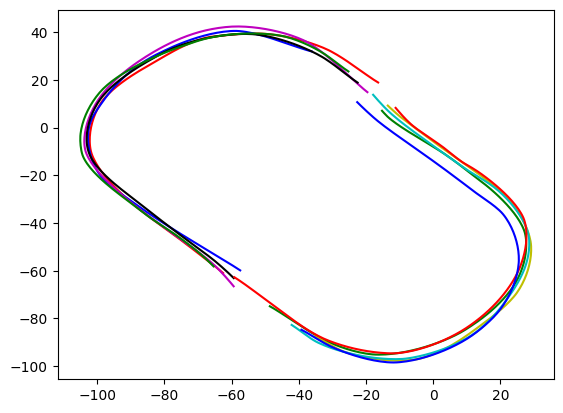

In [8]:
#  Segmentation
tkl.segmentation(trace, ["absdv"], "speed_decoup", [1.5])

# ------------------------------------------------------------------
# + récupération d'un sous-ensemble de traces
# + interpolation/lissage + ré-estimation des vitesses...
# ------------------------------------------------------------------
segmentedTracks = tkl.split(trace, "speed_decoup", limit=50)

# Affichage
COLORS = ['k-','r-','g-','b-','y-','m-','c-']

count = 0
tkl.SPLINE_PENALIZATION = 1e-2
for track in segmentedTracks:
    count += 1
    track.resample(1, tkl.ALGO_THIN_SPLINES, tkl.MODE_SPATIAL)
    track.estimate_speed()
    diff = track.getLastObs().timestamp - track.getFirstObs().timestamp
    v = round(track.length()/diff*3.6,2)
    vm = round(track.operate(tkl.Operator.MAX, "speed")*3.6,2)
    vc = round(100/(track.getObs(150).timestamp-track.getObs(50).timestamp)*3.6,2)
    print("Rep", count, ":  vmoy = ", v, "km/h   vmax = ", vm, " km/h   vc = ", vc, "km/h")
    plt.plot(track.getX(), track.getY(), COLORS[count%7])

plt.show()